# 🛍️ Customer Segmentation using K-Means Clustering

---

## 📌 Project Overview

In this project, we analyze a **retail company's customer data** to group customers into meaningful segments based on their behavior, demographics, and spending patterns.

By the end of this project, we will:
- Clean and prepare the data
- Explore patterns through visualizations
- Build a **K-Means Clustering** model
- Understand **who each customer segment is** and what they mean for business

---

## 📂 Dataset Columns at a Glance

| Column | Description |
|---|---|
| `Year_Birth` | Customer's birth year |
| `Education` | Education level |
| `Marital_Status` | Marital status |
| `Income` | Annual household income |
| `Kidhome / Teenhome` | Number of kids / teens at home |
| `Dt_Customer` | Date customer joined |
| `Recency` | Days since last purchase (lower = more recent) |
| `MntWines, MntFruits, ...` | Amount spent on each product category |
| `NumWebPurchases / NumStorePurchases` | Purchase channel counts |
| `AcceptedCmp1–5, Response` | Whether customer accepted marketing campaigns |

---

## 📦 Step 1 — Import Libraries

We start by importing all the tools we need:
- **pandas & numpy** → for data manipulation
- **matplotlib & seaborn** → for visualizations
- **sklearn** → for machine learning (scaling, clustering, PCA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Make all plots look clean and consistent
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---

## 📥 Step 2 — Load the Dataset

We load the CSV file and take a quick first look at its shape and first few rows.

In [2]:
df = pd.read_csv('raw_customer_data.csv')

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset Shape: 2240 rows × 29 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


---

## 🧹 Step 3 — Data Cleaning

Before any analysis, we must clean the data. We will:
1. Check for and remove **duplicate rows**
2. Check for and remove **missing values**
3. Remove **outliers** in Age and Income that don't make real-world sense

> 💡 **Why?** Dirty data leads to wrong conclusions. Garbage in = Garbage out.

In [3]:
# --- Check for duplicates ---
print(f'Duplicate rows found: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)

# --- Check for missing values ---
print(f'\nMissing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])
df.dropna(inplace=True)

print(f'\n✅ After cleaning: {df.shape[0]} rows × {df.shape[1]} columns')

Duplicate rows found: 0

Missing values per column:
Income    24
dtype: int64

✅ After cleaning: 2216 rows × 29 columns


In [4]:
# --- Convert join date to datetime ---
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# --- Remove unrealistic Age values (Year_Birth before 1930 = Age > 95) ---
df = df[df['Year_Birth'] >= 1930]

# --- Remove Income outliers using IQR method ---
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Income'] >= Q1 - 1.5 * IQR) & (df['Income'] <= Q3 + 1.5 * IQR)]

print(f'✅ Clean dataset ready: {df.shape[0]} rows remaining')

✅ Clean dataset ready: 2205 rows remaining


---

## 🔧 Step 4 — Feature Engineering

The raw dataset doesn't directly have all the useful columns we need. We create new, meaningful features:

| New Feature | How it's made | What it tells us |
|---|---|---|
| `Age` | 2025 - Year_Birth | Customer's current age |
| `Total_Children` | Kidhome + Teenhome | Total dependants at home |
| `Total_Spending` | Sum of all Mnt columns | How much they spend overall |
| `Customer_Since` | Days from join date to today | Customer loyalty/tenure |
| `AcceptedAny` | Any campaign accepted = 1 | Responsiveness to marketing |

In [5]:
# Age
df['Age'] = 2025 - df['Year_Birth']

# Total children at home
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Total money spent across all product categories
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spend_cols].sum(axis=1)

# Days since customer joined
df['Customer_Since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days

# Age groups for EDA
bins   = [18, 30, 40, 50, 60, 70, 90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Campaign response (accepted any = 1)
camp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
             'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['AcceptedAny'] = df[camp_cols].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

print('✅ All new features created!')
df[['Age', 'Total_Children', 'Total_Spending', 'Customer_Since', 'AcceptedAny']].head()

✅ All new features created!


,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny
0,68,0,1617,4986,1
1,71,2,27,4436,0
2,60,0,776,4635,0
3,41,1,53,4462,0
4,44,1,422,4484,0


---

## 📊 Step 5 — Exploratory Data Analysis (EDA)

Now we **visualize the data** to understand the distribution of key variables and spot interesting patterns.

### 5.1 — Distribution of Key Variables

We look at how Age, Income, and Total Spending are spread across customers.

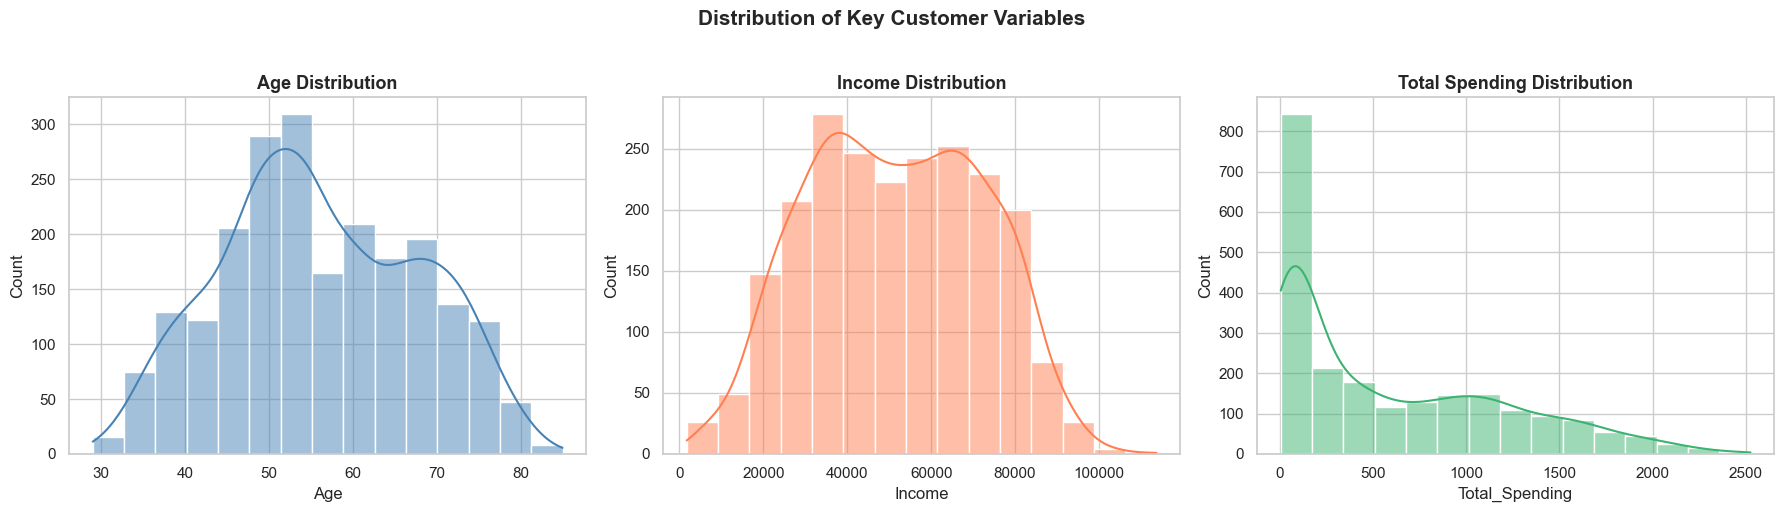

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color, title in zip(
    axes,
    ['Age', 'Income', 'Total_Spending'],
    ['steelblue', 'coral', 'mediumseagreen'],
    ['Age Distribution', 'Income Distribution', 'Total Spending Distribution']
):
    sns.histplot(df[col], bins=15, kde=True, color=color, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Key Customer Variables', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 — Income & Spending by Demographics

We check how **Income varies by Education** and how **Spending varies by Marital Status**.

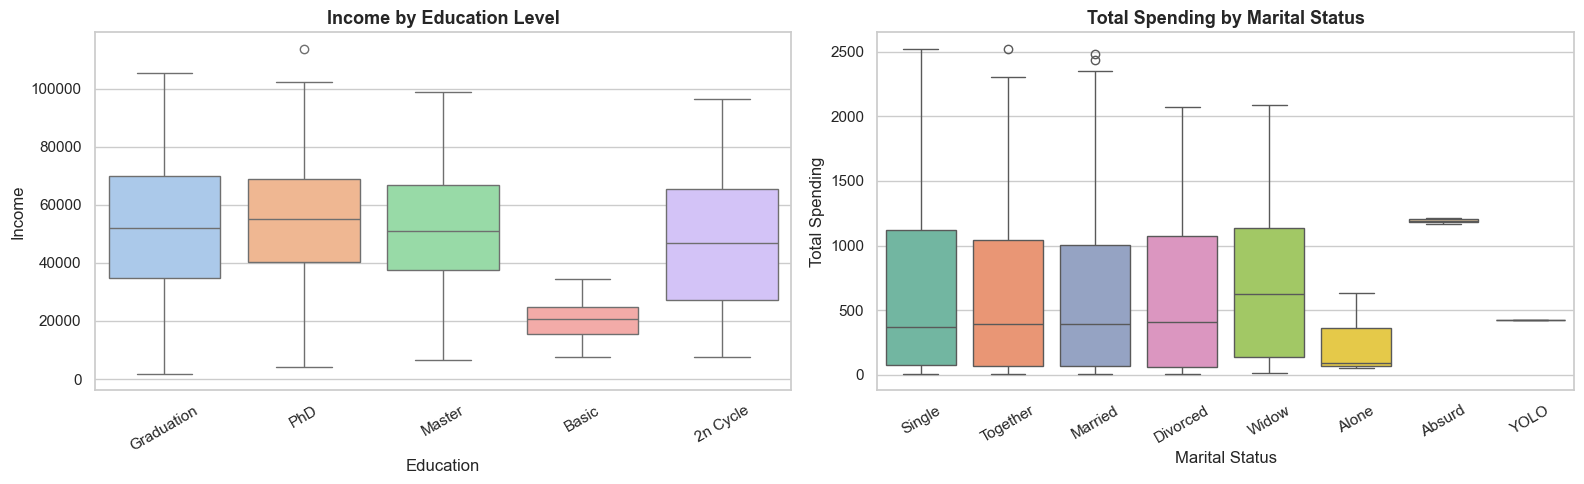

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Income by Education
sns.boxplot(x='Education', y='Income', data=df, palette='pastel', ax=axes[0])
axes[0].set_title('Income by Education Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Income')
axes[0].tick_params(axis='x', rotation=30)

# Spending by Marital Status
sns.boxplot(x='Marital_Status', y='Total_Spending', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Total Spending by Marital Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Total Spending')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 5.3 — Correlation Heatmap

A **correlation matrix** shows how strongly two variables are related.
- Values close to **+1** → strong positive relationship
- Values close to **-1** → strong negative relationship
- Values near **0** → no relationship

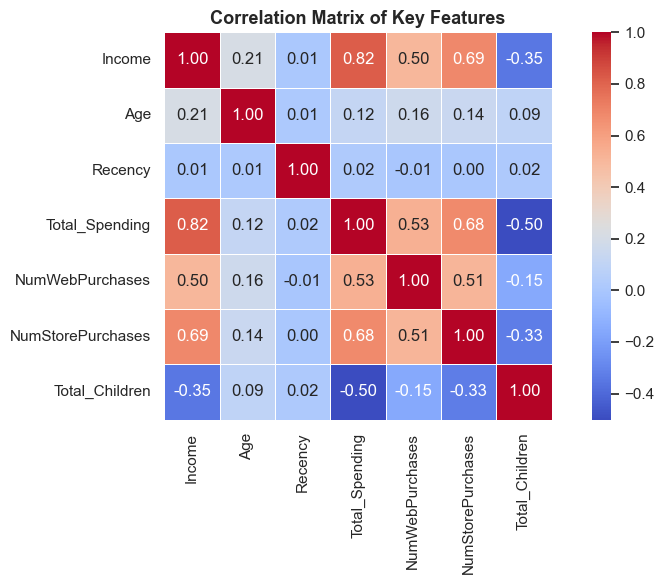

In [8]:
corr_cols = ['Income', 'Age', 'Recency', 'Total_Spending',
             'NumWebPurchases', 'NumStorePurchases', 'Total_Children']
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 — Group Analysis

We now look at **average spending by Education** and **average income by Age Group** to see if clear patterns emerge across demographic groups.

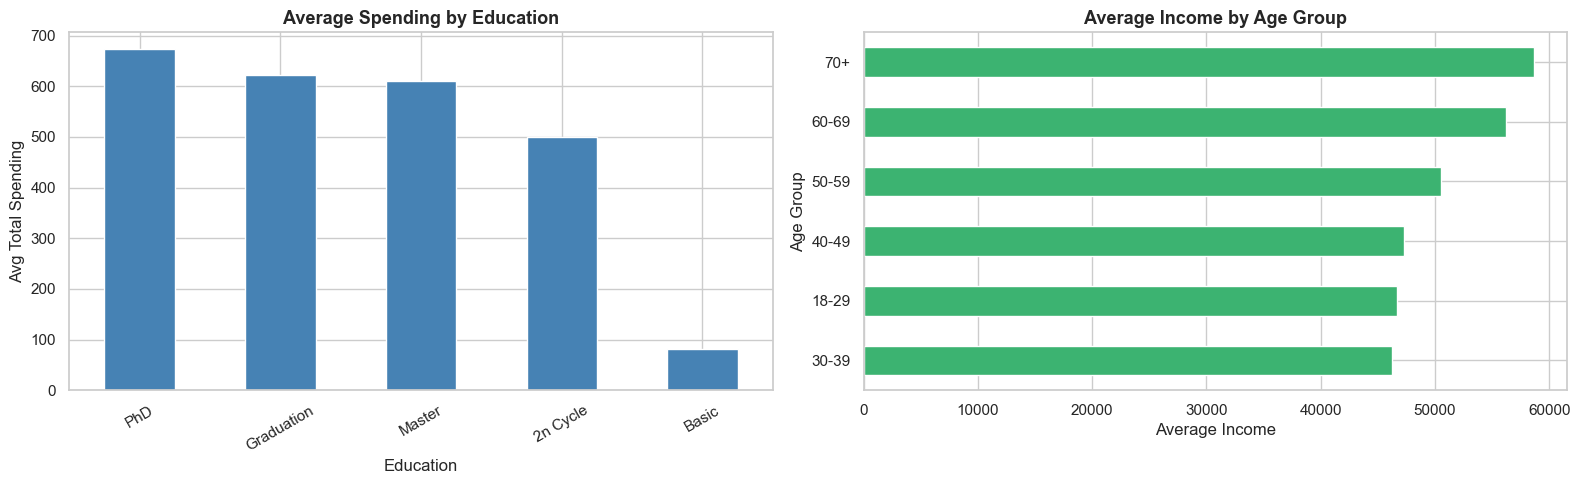

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average Spending by Education
group1 = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending=False)
group1.plot(kind='bar', color='steelblue', ax=axes[0], edgecolor='white')
axes[0].set_title('Average Spending by Education', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Total Spending')
axes[0].set_xlabel('Education')
axes[0].tick_params(axis='x', rotation=30)

# Average Income by Age Group
group2 = df.groupby('Age_Group', observed=True)['Income'].mean().sort_values()
group2.plot(kind='barh', color='mediumseagreen', ax=axes[1], edgecolor='white')
axes[1].set_title('Average Income by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Income')
axes[1].set_ylabel('Age Group')

plt.tight_layout()
plt.show()

### 5.5 — Campaign Acceptance Rate by Marital Status

Which customer groups are **most responsive to marketing campaigns**?

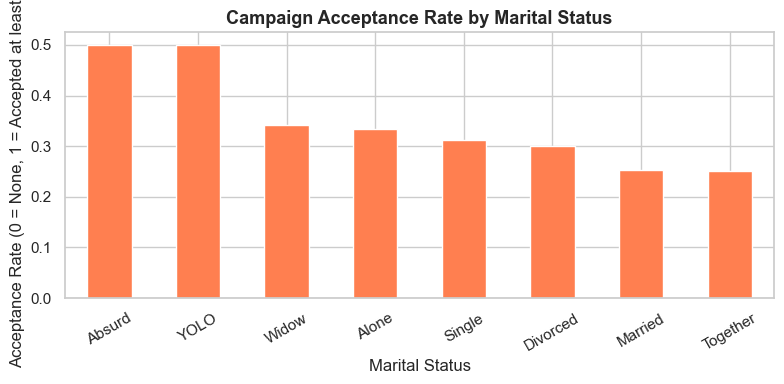

In [10]:
group3 = df.groupby('Marital_Status')['AcceptedAny'].mean().sort_values(ascending=False)

group3.plot(kind='bar', color='coral', edgecolor='white', figsize=(8, 4))
plt.title('Campaign Acceptance Rate by Marital Status', fontsize=13, fontweight='bold')
plt.ylabel('Acceptance Rate (0 = None, 1 = Accepted at least one)')
plt.xlabel('Marital Status')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---

## ⚙️ Step 6 — Prepare Features for Clustering

We select the features that best describe customer **behavior and value**, then scale them.

> 💡 **Why scale?** K-Means uses distance. If Income is in the thousands and Recency is in single digits, Income will dominate unfairly. Scaling puts all features on the same level.

In [11]:
features = [
    'Age',               # Who they are
    'Income',            # Their financial capacity
    'Total_Spending',    # How much they spend
    'NumWebPurchases',   # Online shopping behavior
    'NumStorePurchases', # In-store shopping behavior
    'NumDealsPurchases', # Discount-seeking behavior
    'NumWebVisitsMonth', # Engagement level
    'Recency'            # How recently they purchased (lower = more active)
]

X = df[features].copy()

# Scale features to have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Feature matrix ready: {X_scaled.shape[0]} customers × {X_scaled.shape[1]} features')

✅ Feature matrix ready: 2205 customers × 8 features


---

## 🔍 Step 7 — Finding the Optimal Number of Clusters

We use **two methods** together to pick the best number of clusters (k):

- **Elbow Method** → plots WCSS (Within-Cluster Sum of Squares). Look for the "elbow" point where the drop slows down.
- **Silhouette Score** → measures how well-separated the clusters are. Higher is better (max = 1).

> 💡 Using both methods together gives us much more confidence in our choice of k.

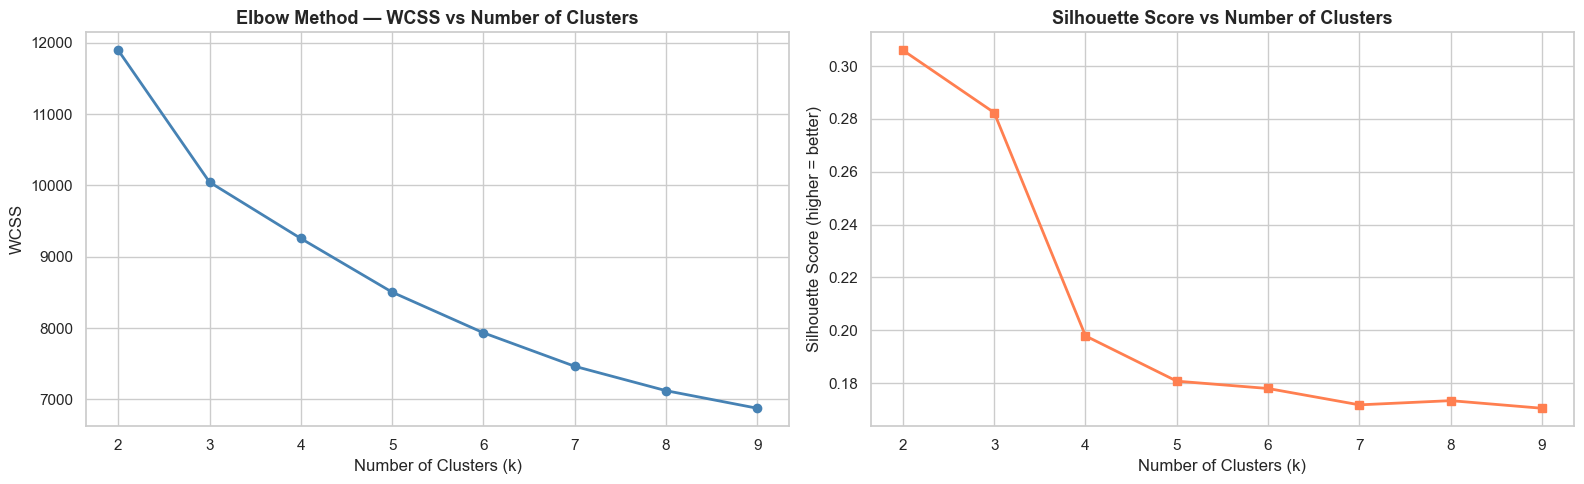


Silhouette Scores:
  k=2: 0.3060
  k=3: 0.2823
  k=4: 0.1979
  k=5: 0.1807
  k=6: 0.1779
  k=7: 0.1718
  k=8: 0.1733
  k=9: 0.1705


In [12]:
wcss = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, wcss, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — WCSS vs Number of Clusters', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS')

axes[1].plot(K_range, sil_scores, marker='s', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
plt.show()

print('\nSilhouette Scores:')
for k, s in zip(K_range, sil_scores):
    print(f'  k={k}: {s:.4f}')

---

## 🤖 Step 8 — Train the K-Means Model

Based on the elbow and silhouette analysis above, we choose our optimal k and fit the final model.

> 💡 `random_state=42` ensures we get the **same result every time** we run this notebook.

In [13]:
OPTIMAL_K = 4  # Adjust based on elbow/silhouette plots above

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'✅ KMeans model trained with k={OPTIMAL_K}')
print(f'\nCustomers per cluster:')
print(df['Cluster'].value_counts().sort_index())

✅ KMeans model trained with k=4

Customers per cluster:
Cluster
0    437
1    532
2    501
3    735
Name: count, dtype: int64


### Cluster Size Distribution

A healthy clustering should not have clusters that are too tiny or too dominant. Let's visualize the size of each cluster.

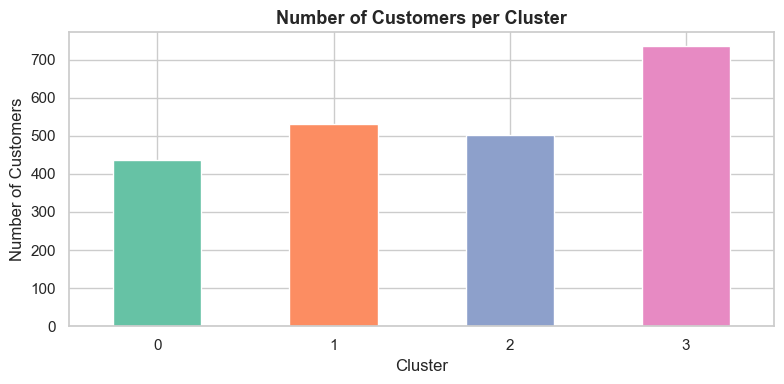

In [14]:
cluster_counts = df['Cluster'].value_counts().sort_index()

cluster_counts.plot(kind='bar', color=sns.color_palette('Set2', OPTIMAL_K),
                    edgecolor='white', figsize=(8, 4))
plt.title('Number of Customers per Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

## 📋 Step 9 — Cluster Profiles

Now we look at the **average values** of each feature per cluster to understand what makes each group unique.

In [15]:
cluster_summary = df.groupby('Cluster')[features].mean().round(1)
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,,
0,59.9,54255.6,717.2,6.9,7.2,4.8,6.7,49.5
1,51.8,33380.7,97.7,2.0,3.2,1.9,6.5,24.9
2,55.5,36004.5,117.1,2.2,3.4,2.0,6.3,75.2
3,57.4,73905.1,1243.5,5.2,8.6,1.4,3.0,48.3


### Spending Breakdown by Cluster

Let's see **what each cluster spends money on** — this helps us design targeted product promotions.

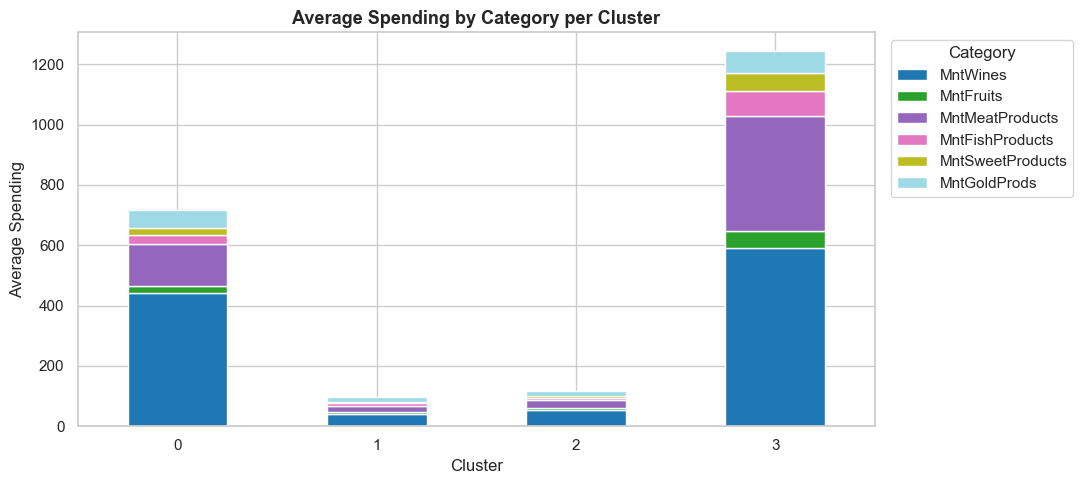

In [16]:
spend_summary = df.groupby('Cluster')[spend_cols].mean()

spend_summary.plot(kind='bar', stacked=True,
                   colormap='tab20', figsize=(11, 5), edgecolor='white')
plt.title('Average Spending by Category per Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Average Spending')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Radar Chart — Cluster Comparison

A radar chart lets us compare **all clusters across all features at once** — perfect for spotting differences between segments.

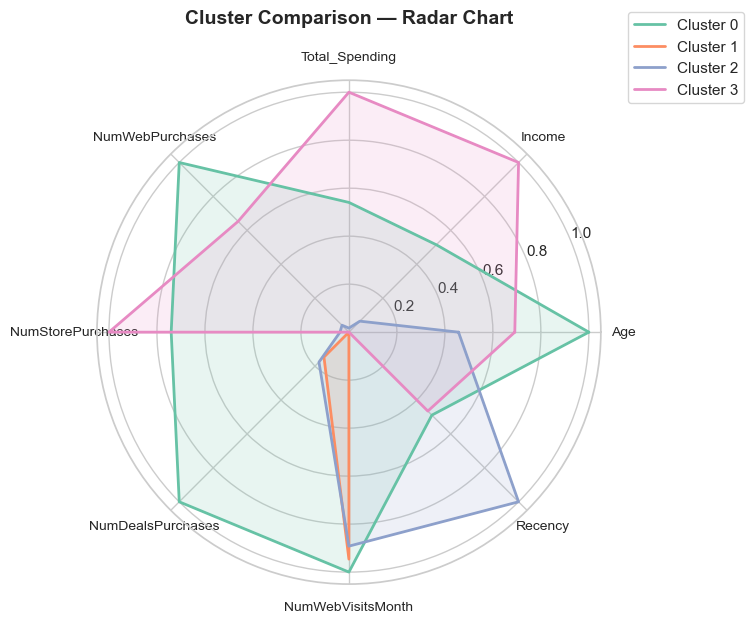

In [17]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalize cluster summary to 0-1 for radar
radar_data = cluster_summary.copy()
radar_data = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

radar_features = features
N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = sns.color_palette('Set2', OPTIMAL_K)

for i, row in radar_data.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, color=colors[i], linewidth=2, label=f'Cluster {i}')
    ax.fill(angles, vals, color=colors[i], alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=10)
ax.set_title('Cluster Comparison — Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))
plt.tight_layout()
plt.show()

---

## 🗺️ Step 10 — Visualize Clusters with PCA

Our data has 8 features, which is impossible to plot directly. We use **PCA (Principal Component Analysis)** to compress it down to **2 dimensions** so we can visualize the clusters.

> 💡 PCA doesn't throw away information — it finds the 2 most important directions in the data.

Variance explained by 2 components: 59.1%


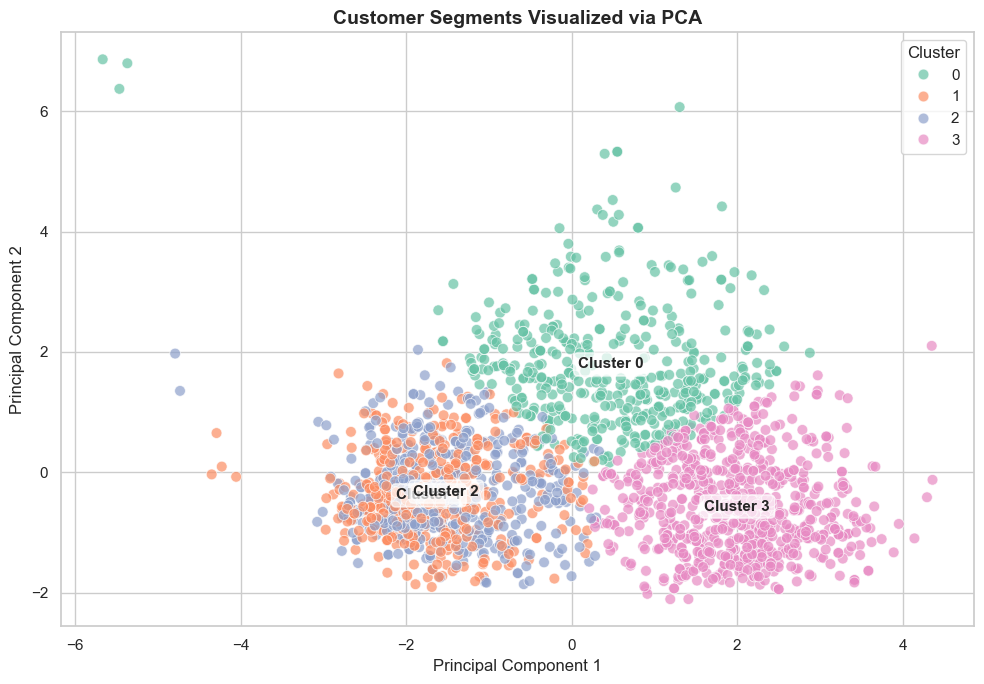

In [18]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

print(f'Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster', data=df,
    palette='Set2', s=60, alpha=0.7, edgecolor='white'
)

# Annotate cluster centers
for cluster_id in df['Cluster'].unique():
    cx = df[df['Cluster'] == cluster_id]['PCA1'].mean()
    cy = df[df['Cluster'] == cluster_id]['PCA2'].mean()
    plt.annotate(f'Cluster {cluster_id}', (cx, cy),
                 fontsize=11, fontweight='bold',
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.title('Customer Segments Visualized via PCA', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

---

## 🏷️ Step 11 — Cluster Labels & Business Interpretation

Based on the cluster profiles, we assign a meaningful business label to each segment.

> Update the labels below after reviewing your `cluster_summary` table above.

In [19]:
# Assign names based on cluster_summary insights
cluster_labels = {
    0: 'Premium Customers',    # High income, high spending
    1: 'Budget Shoppers',      # Low income, low spending
    2: 'Digital Buyers',       # High web purchases, low store
    3: 'Dormant Customers',    # High recency (not purchased recently)
}

df['Segment'] = df['Cluster'].map(cluster_labels)

print('Segment distribution:')
print(df['Segment'].value_counts())

Segment distribution:
Segment
Dormant Customers    735
Budget Shoppers      532
Digital Buyers       501
Premium Customers    437
Name: count, dtype: int64


---

## 💾 Step 12 — Save the Model & Export Results

We save:
- The **trained KMeans model** and **scaler** → for future use on new customers
- The **final dataset with cluster labels** → for business reporting

In [20]:
import joblib

# Save model and scaler
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Export segmented customer data
df.to_csv('customer_segments_output.csv', index=False)

print('✅ Model saved: kmeans_model.pkl')
print('✅ Scaler saved: scaler.pkl')
print('✅ Results exported: customer_segments_output.csv')

✅ Model saved: kmeans_model.pkl
✅ Scaler saved: scaler.pkl
✅ Results exported: customer_segments_output.csv


---

## ✅ Step 13 — Conclusion

### What We Did

| Step | What We Did |
|---|---|
| Data Cleaning | Removed duplicates, nulls, and outliers in Age & Income |
| Feature Engineering | Created Age, Total_Spending, Total_Children, Customer_Since |
| EDA | Explored distributions, correlations, and group behavior |
| Clustering | Used Elbow + Silhouette to justify k, then fit KMeans |
| Interpretation | Profiled each segment with radar chart & spending breakdown |
| Export | Saved model, scaler, and final segmented dataset |

### Business Takeaways

- 🏆 **Premium Customers** → Offer loyalty programs and premium product recommendations
- 💰 **Budget Shoppers** → Target with discounts, deals, and value bundles
- 🌐 **Digital Buyers** → Improve online experience, email campaigns, web-only offers
- 😴 **Dormant Customers** → Send re-engagement campaigns, win-back offers

---
*Customer Segmentation Project | Built with K-Means Clustering & Python*